In [9]:
import sqlite3
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from scipy import stats
import os
from dotenv import load_dotenv

# Config
load_dotenv()
DB_NAME = os.getenv('DB_NAME', 'jobscope.db')
conn = sqlite3.connect(DB_NAME)

# Load data
df = pd.read_sql('SELECT * FROM clean_jobs', conn)

# Parse the extracted_skills JSON column into actual Python lists
df['skills_list'] = df['extracted_skills'].apply(json.loads)
df['num_skills'] = df['skills_list'].apply(len)

# Parse dates
# df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce', utc=True)

# Style settings — consistent look across all charts
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PALETTE = sns.color_palette("viridis", 8)
sns.set_style("whitegrid")

print(f"Loaded {len(df)} clean jobs")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 2368 clean jobs
Columns: ['id', 'raw_job_id', 'title_original', 'title_normalized', 'role_category', 'company', 'description_clean', 'location_raw', 'location_city', 'location_region', 'salary_min', 'salary_max', 'salary_mid', 'has_real_salary', 'extracted_skills', 'date_posted', 'seniority', 'job_source', 'skills_list', 'num_skills']


/var/folders/10/nnvj7_7d7gd5rlpp9w3538dm0000gp/T/ipykernel_44766/887519000.py:27: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce', utc=True)


,id,raw_job_id,title_original,title_normalized,role_category,company,description_clean,location_raw,location_city,location_region,salary_min,salary_max,salary_mid,has_real_salary,extracted_skills,date_posted,seniority,job_source,skills_list,num_skills
0,6781,1,Junior Data Scientist,Junior Data Scientist,Data Scientist,Newto Training,are you ready to start a new career in data an...,UK,UK-wide,UK-wide,44849.22,44849.22,44849.22,0,"[""data analysis"", ""data analytics"", ""excel""]",2026-02-19 18:28:35+00:00,junior,adzuna,"[data analysis, data analytics, excel]",3
1,6782,2,Data Scientist,Data Scientist,Data Scientist,Provide,data scientist – mro ai solutions (embedded in...,"Heathrow, Hounslow",Heathrow,Other UK,70672.75,70672.75,70672.75,0,[],2026-02-27 14:55:45+00:00,mid,adzuna,[],0
2,6783,3,Data Scientist,Data Scientist,Data Scientist,True North Group,data scientist newcastle upon tyne (hybrid wor...,"Newcastle Upon Tyne, Tyne & Wear",Newcastle Upon Tyne,North East,41343.96,41343.96,41343.96,0,"[""machine learning""]",2026-02-27 14:30:03+00:00,mid,adzuna,[machine learning],1
3,6784,4,Senior Data Scientist,Senior Data Scientist,Data Scientist,E-Solutions IT Services UK Ltd,role: senior data scientist location: manchest...,"Manchester, Greater Manchester",Manchester,North West,51727.38,51727.38,51727.38,0,[],2026-02-23 23:29:21+00:00,senior,adzuna,[],0
4,6785,5,Lead Data Scientist,Lead Data Scientist,Data Scientist,Ocho,job description lead data scientist location: ...,"Belfast, Northern Ireland",Belfast,Northern Ireland,80000.00,80000.00,80000.00,0,"[""leadership"", ""mentoring""]",2026-02-26 03:27:24+00:00,senior,adzuna,"[leadership, mentoring]",2


# JobScope UK — UK Data & AI Job Market Analysis

**Dataset:** 2,368 cleaned job postings from Adzuna and Reed APIs, collected March 2026.  
**Scope:** Data Analyst, Data Scientist, Data Engineer, ML Engineer, AI Engineer, BI Analyst, LLM Engineer, NLP Engineer roles across the UK.

## 1. Dataset Overview

In [10]:
# Source breakdown
source_counts = df['job_source'].value_counts()
print(f"Adzuna: {source_counts.get('adzuna', 0)}")
print(f"Reed: {source_counts.get('reed', 0)}")
print(f"\nDate range: {df['date_posted'].min().date()} to {df['date_posted'].max().date()}")

Adzuna: 1388
Reed: 980

Date range: 2023-05-11 to 2026-12-03


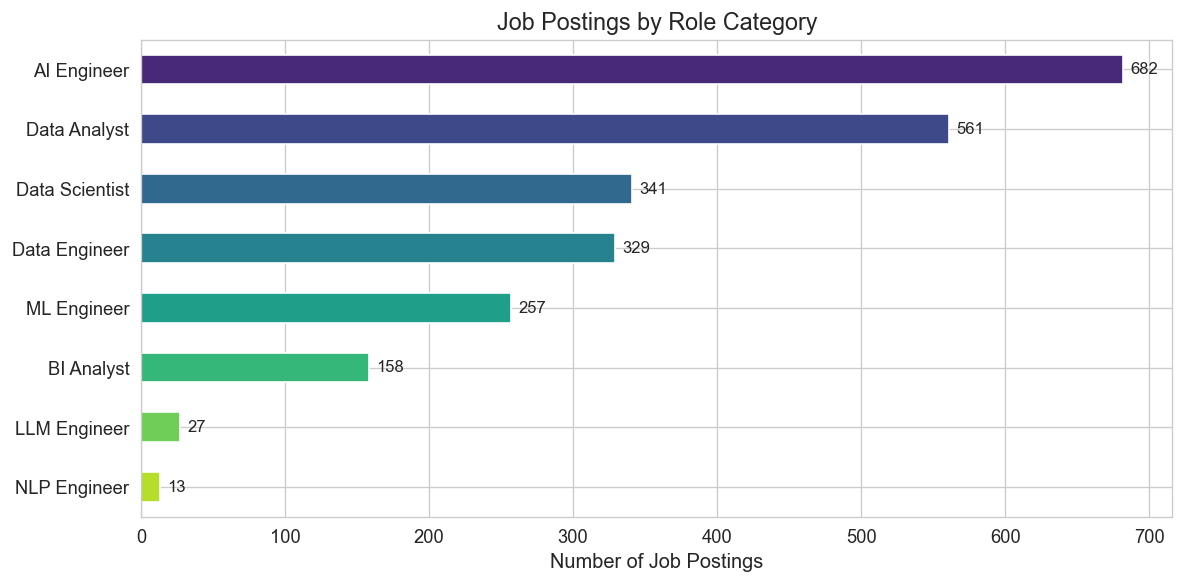

In [13]:
# Role category distribution
fig, ax = plt.subplots(figsize=(10, 5))
role_counts = df['role_category'].value_counts()
role_counts.plot(kind='barh', ax=ax, color=PALETTE[:len(role_counts)])
ax.set_xlabel('Number of Job Postings')
ax.set_title('Job Postings by Role Category')
ax.invert_yaxis()  # Largest on top
for i, v in enumerate(role_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/role_distribution.png', bbox_inches='tight')
plt.show()

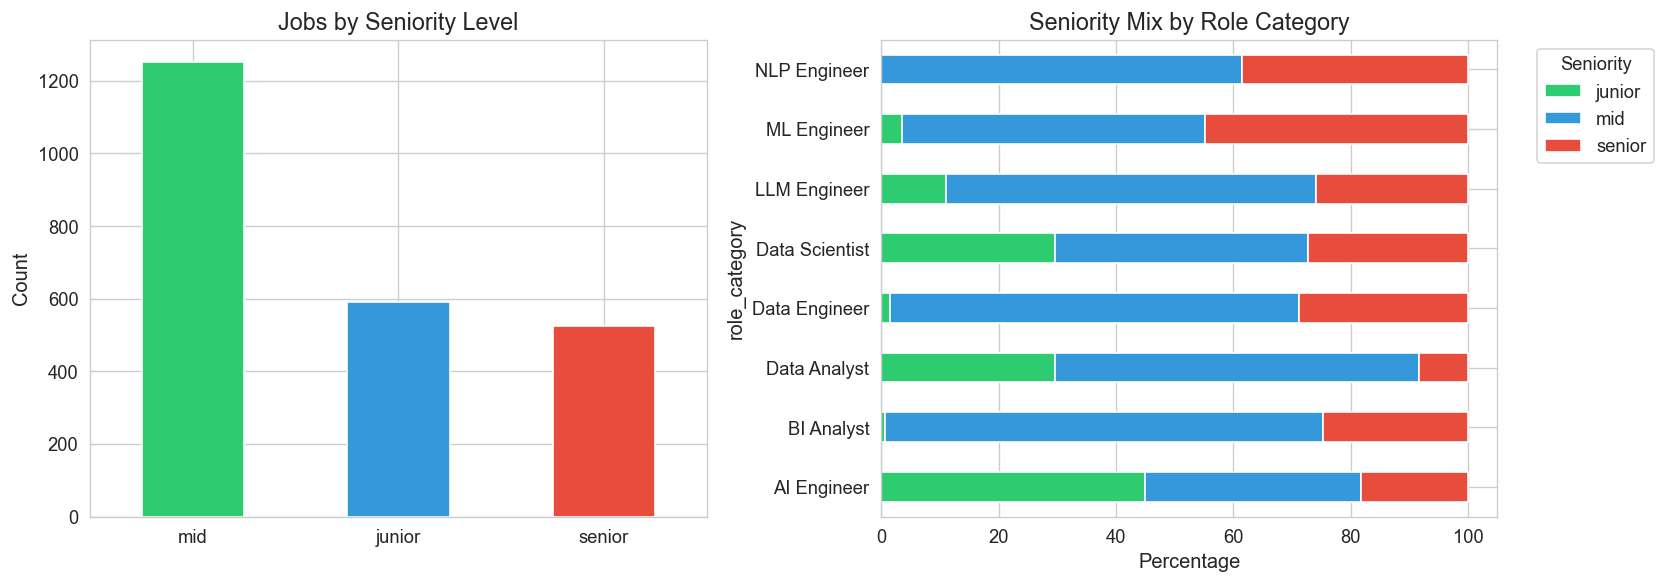

In [14]:
# Seniority distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall seniority
sen_counts = df['seniority'].value_counts()
sen_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Jobs by Seniority Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Seniority within each role
sen_role = df.groupby(['role_category', 'seniority']).size().unstack(fill_value=0)
sen_role_pct = sen_role.div(sen_role.sum(axis=1), axis=0) * 100
sen_role_pct.plot(kind='barh', stacked=True, ax=axes[1], 
                   color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Seniority Mix by Role Category')
axes[1].set_xlabel('Percentage')
axes[1].legend(title='Seniority', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('outputs/seniority_distribution.png', bbox_inches='tight')
plt.show()